### What is Linear Regression?

Linear Regression is a supervised machine learning algorithm used to model the relationship between input features (X) and a target variable (y).

It assumes a linear relationship between input and output:

y = Wx + b

Where:
- W = weight (slope of the line)
- b = bias (intercept)

The goal is to find the best values of W and b such that the predicted values are as close as possible to the actual values.

In [41]:
# Import

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

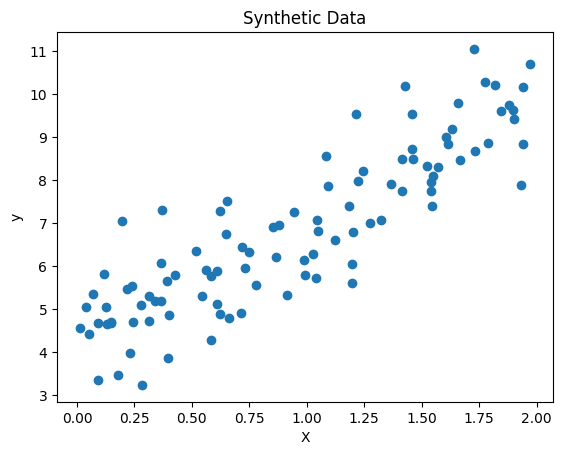

In [42]:
# Understanding data visually

plt.scatter(X, y)
plt.title("Synthetic Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Intuition

Linear Regression tries to fit a straight line through the data points.

The "best" line is the one that minimizes the difference between:
- Actual values (y)
- Predicted values (y_pred)

This difference is called the error.

The model improves by adjusting the line until the error is minimized.

In [43]:
# Initialize Parameters

W = np.random.randn(1, 1)
b = np.random.randn(1)

### Forward Pass (Prediction)

The forward pass is the step where the model makes predictions using current parameters.

Formula:
y_pred = XW + b

Here:
- X is the input data
- W is the weight
- b is the bias

This is essentially a matrix multiplication followed by adding a bias term.

### Loss Function (Mean Squared Error)

To measure how good or bad the model is, we use a loss function.

We use Mean Squared Error (MSE):

L = (1/m) * Σ(y - y_pred)²

Where:
- y = actual value
- y_pred = predicted value
- m = number of samples

The goal of training is to minimize this loss.

### What are Gradients?

Gradients tell us how to adjust the model parameters (W and b) to reduce the loss.

They represent the direction and magnitude of change needed.

- If gradient is large → big update
- If gradient is small → small update

We use gradients to move towards the minimum loss.

In [44]:
# Forward Pass

def predict(X, W, b):
    return X @ W + b

# Loss Function (MSE)

def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Gradients

def compute_gradients(X, y, y_pred):
    m = len(X)
    
    dW = (-2/m) * X.T @ (y - y_pred)
    db = (-2/m) * np.sum(y - y_pred)
    # print("dW:", dW)
    # print("db:", db)
    
    return dW, db


### Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the loss function.

It updates the parameters iteratively using:

W = W - learning_rate * dW
b = b - learning_rate * db

Where:
- dW and db are gradients
- learning_rate controls how big each step is

We move in the opposite direction of the gradient to reduce the error.

### Training Loop

Training is an iterative process where the model improves over time.

Steps:
1. Make predictions (forward pass)
2. Compute loss
3. Compute gradients
4. Update parameters
5. Repeat for multiple epochs

Over time, the loss decreases and the model learns the pattern in the data.

### Learning Rate

Learning rate determines how much we update the parameters in each step.

- Too high → model may overshoot and not converge
- Too low → training becomes very slow

Choosing the right learning rate is important for efficient training.

In [45]:
# Training Loop

losses = []

learning_rate = 0.01
epochs = 500

for epoch in range(epochs):
    y_pred = predict(X, W, b)
    
    loss = compute_loss(y, y_pred)
    losses.append(loss)   # ✅ Track here
    
    dW, db = compute_gradients(X, y, y_pred)
    
    W -= learning_rate * dW
    b -= learning_rate * db
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 32.138586076383035
Epoch 10, Loss: 14.290110205649821
Epoch 20, Loss: 6.611726403379552
Epoch 30, Loss: 3.308328296738578
Epoch 40, Loss: 1.8869794105294075
Epoch 50, Loss: 1.2752686205342254
Epoch 60, Loss: 1.0118655449910001
Epoch 70, Loss: 0.8983141942359012
Epoch 80, Loss: 0.8492417885011365
Epoch 90, Loss: 0.8279216814213756
Epoch 100, Loss: 0.8185538564218227
Epoch 110, Loss: 0.8143405645549897
Epoch 120, Loss: 0.8123567060980438
Epoch 130, Loss: 0.81134317078753
Epoch 140, Loss: 0.8107575747187608
Epoch 150, Loss: 0.810365903548956
Epoch 160, Loss: 0.8100668426403621
Epoch 170, Loss: 0.8098162045272077
Epoch 180, Loss: 0.809594416379602
Epoch 190, Loss: 0.8093925311720005
Epoch 200, Loss: 0.8092062075382246
Epoch 210, Loss: 0.8090331177510827
Epoch 220, Loss: 0.8088718305601468
Epoch 230, Loss: 0.8087213286229629
Epoch 240, Loss: 0.8085807990559783
Epoch 250, Loss: 0.808449541598073
Epoch 260, Loss: 0.8083269274827073
Epoch 270, Loss: 0.8082123802304882
Epoch 280,

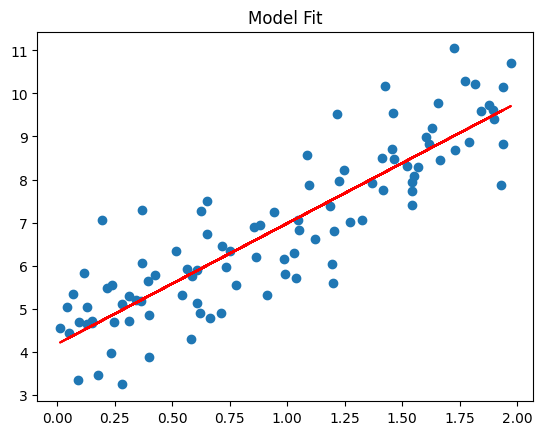

In [46]:
# Final Prediction Line

plt.scatter(X, y)
plt.plot(X, predict(X, W, b), color='red')
plt.title("Model Fit")
plt.show()

### Observations

- The loss decreases over time, indicating the model is learning
- The predicted line gradually fits the data better
- Gradient descent helps find optimal parameters

This demonstrates how machine learning models learn from data through optimization.

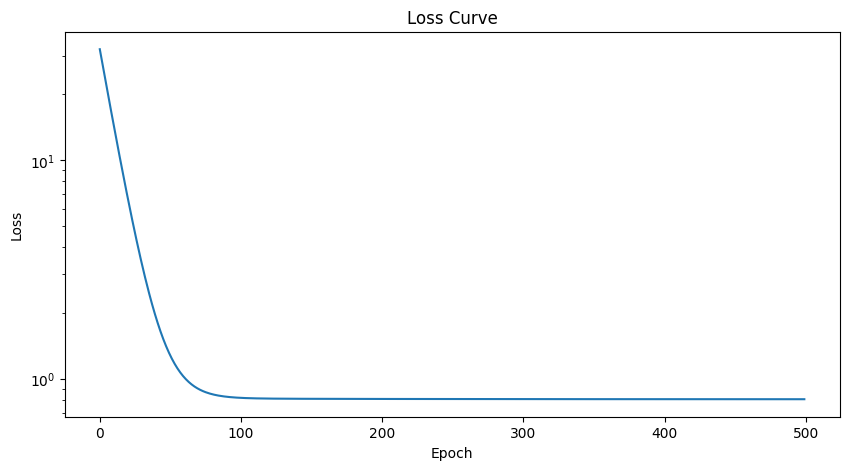

In [47]:
# Loss vs Epoch

plt.figure(figsize=(10,5))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.show()

### Loss Curve Observation

The loss curve shows a rapid decrease in the initial epochs, followed by a gradual flattening.

This indicates:
- The model quickly learns the main pattern in the data
- Gradients decrease over time as the model approaches optimal parameters
- The model converges to a stable solution

Using a log scale helps visualize both rapid initial learning and slow convergence.

### Key Takeaway

This implementation shows how machine learning models work internally.

Libraries like PyTorch and TensorFlow automate these steps, 
but understanding the underlying process is crucial for building and debugging models effectively.